In [1]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


In [26]:
# =========================
# PATHS
# =========================
DATA_DIR = r"D:\PROJECT -MTech\Datasets_SARCASM\MALAYALAM"
RESULT_DIR = r"D:\PROJECT -MTech\S4\results\evidential_deep\CNN"

os.makedirs(RESULT_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "sarcasm_mal_train.csv")
DEV_PATH   = os.path.join(DATA_DIR, "sarcasm_mal_dev.csv")
TEST_PATH  = os.path.join(DATA_DIR, "sarcasm_mal_test.csv")

DEVICE = torch.device("cpu")


In [27]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


In [28]:
train_df = pd.read_csv(TRAIN_PATH)
dev_df   = pd.read_csv(DEV_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(train_df.head())
print(train_df['labels'].value_counts())


                                                Text         labels
0  ആദ്യം കേട്ടിട്ട് ഇഷ്ടായില്ല  ഇപ്പൊ വീണ്ടും  വീ...  Non-sarcastic
1  1:07 . ezhuthi kaanichathu kondu aaranennu man...  Non-sarcastic
2                   Uyyantaa moneee,   ikkaa uyyyrrr      Sarcastic
3                         K J Yesudas fans like here  Non-sarcastic
4  Bollywood moviyude oru feel തോന്നിയവർ ലൈക് അടി...  Non-sarcastic
labels
Non-sarcastic    9798
Sarcastic        2259
Name: count, dtype: int64


In [29]:
MAX_VOCAB = 20000
MAX_LEN = 50


In [30]:
from collections import Counter

def build_vocab(texts, max_vocab):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    vocab = {w:i+2 for i,(w,_) in enumerate(counter.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

vocab = build_vocab(train_df['Text'], MAX_VOCAB)
VOCAB_SIZE = len(vocab)


In [31]:
def encode(text):
    tokens = text.split()
    ids = [vocab.get(t, 1) for t in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))
    return ids


In [32]:
class SarcasmDataset(Dataset):
    def __init__(self, df):
        self.texts = df['Text'].values
        self.labels = df['labels'].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


In [33]:
BATCH_SIZE = 32

train_loader = DataLoader(SarcasmDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(SarcasmDataset(dev_df), batch_size=BATCH_SIZE)


In [34]:
class EvidentialCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_classes=2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)           # (B, L, E)
        x = x.transpose(1, 2)           # (B, E, L)
        x = F.relu(self.conv(x))        # (B, 128, L)
        x = F.max_pool1d(x, x.size(2))  # (B, 128)
        x = x.squeeze(2)

        evidence = F.softplus(self.fc(x))  # 🔥 evidence ≥ 0
        alpha = evidence + 1              # Dirichlet parameters
        return alpha


In [35]:
def evidential_loss(alpha, targets):
    S = torch.sum(alpha, dim=1, keepdim=True)
    probs = alpha / S

    one_hot = F.one_hot(targets, num_classes=alpha.size(1)).float()

    loglikelihood = torch.sum(one_hot * (torch.digamma(S) - torch.digamma(alpha)), dim=1)
    return loglikelihood.mean()


In [36]:
model = EvidentialCNN(VOCAB_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [37]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
            return False


In [38]:
EPOCHS = 30          # max epochs (won't reach usually)
PATIENCE = 3         # early stopping patience

early_stopper = EarlyStopping(patience=PATIENCE)

model = EvidentialCNN(VOCAB_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_model_path = os.path.join(
    RESULT_DIR, "cnn_evidential_seed_42.pt"
)


In [39]:
print(train_df['labels'].unique())
print(train_df['labels'].dtype)


['Non-sarcastic' 'Sarcastic']
object


In [40]:
label_map = {
    "Non-sarcastic": 0,
    "Sarcastic": 1
}

train_df['labels'] = train_df['labels'].map(label_map)
dev_df['labels']   = dev_df['labels'].map(label_map)
test_df['labels']  = test_df['labels'].map(label_map)


In [41]:
print(train_df['labels'].dtype)
print(train_df['labels'].unique())


int64
[0 1]


In [44]:
class SarcasmDataset(Dataset):
    def __init__(self, df):
        self.texts = df['Text'].values
        self.labels = df['labels'].values

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


In [46]:
SEEDS = [1, 7, 21, 42, 100]   # 5-member ensemble (enough for CPU)


In [48]:
def train_single_model(seed):
    print(f"\n🔹 Training model with seed {seed}")
    set_seed(seed)

    model = EvidentialCNN(VOCAB_SIZE).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    early_stopper = EarlyStopping(patience=3)

    model_path = os.path.join(
        RESULT_DIR, f"cnn_evidential_seed_{seed}.pt"
    )

    for epoch in range(30):
        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            alpha = model(x)
            loss = evidential_loss(alpha, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in dev_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                alpha = model(x)
                loss = evidential_loss(alpha, y)
                val_loss += loss.item()

        val_loss /= len(dev_loader)

        print(f"Seed {seed} | Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}")

        improved = early_stopper.step(val_loss)

        if improved:
            torch.save(model.state_dict(), model_path)
            print("   ✓ Best model saved")

        if early_stopper.stop:
            print("   ⛔ Early stopping")
            break

    return model_path


In [50]:
# ===== REBUILD DATASETS AFTER LABEL FIX =====
train_dataset = SarcasmDataset(train_df)
dev_dataset   = SarcasmDataset(dev_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=32,
    shuffle=False
)


TypeError: object of type 'SarcasmDataset' has no len()

In [49]:
model_paths = []

for seed in SEEDS:
    path = train_single_model(seed)
    model_paths.append(path)

print("\nAll models trained:")
for p in model_paths:
    print(p)



🔹 Training model with seed 1


TypeError: new(): invalid data type 'str'

In [55]:
# =========================================================
# STEP 0: FULL CNN + EVIDENTIAL + DEEP ENSEMBLE (CPU, JUPYTER)
# =========================================================

# ---------- IMPORTS ----------
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ---------- PATHS ----------
DATA_DIR = r"D:\PROJECT -MTech\Datasets_SARCASM\MALAYALAM"
RESULT_DIR = r"D:\PROJECT -MTech\S4\results\evidential_deep"
os.makedirs(RESULT_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "sarcasm_mal_train.csv")
DEV_PATH   = os.path.join(DATA_DIR, "sarcasm_mal_dev.csv")

DEVICE = torch.device("cpu")

# ---------- SEED ----------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

# ---------- LOAD DATA ----------
train_df = pd.read_csv(TRAIN_PATH)
dev_df   = pd.read_csv(DEV_PATH)

# ---------- LABEL CLEANING ----------
# if labels are strings like "sarcastic"/"non_sarcastic"
if train_df['labels'].dtype == object:
    train_df['labels'] = train_df['labels'].astype(str).str.strip().str.lower()
    dev_df['labels']   = dev_df['labels'].astype(str).str.strip().str.lower()

    label_map = {
        "Non-sarcastic": 0,
    "Sarcastic": 1,
        "0": 0,
        "1": 1
    }

    train_df['labels'] = train_df['labels'].map(label_map)
    dev_df['labels']   = dev_df['labels'].map(label_map)

# drop invalid labels
train_df = train_df.dropna(subset=['labels'])
dev_df   = dev_df.dropna(subset=['labels'])

train_df['labels'] = train_df['labels'].astype(int)
dev_df['labels']   = dev_df['labels'].astype(int)

print("Label check:", train_df['labels'].unique())

# ---------- TOKENIZER ----------
MAX_VOCAB = 20000
MAX_LEN   = 50

from collections import Counter

def build_vocab(texts):
    counter = Counter()
    for t in texts:
        counter.update(str(t).split())
    vocab = {w: i+2 for i,(w,_) in enumerate(counter.most_common(MAX_VOCAB))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

vocab = build_vocab(train_df['Text'])
VOCAB_SIZE = len(vocab)

def encode(text):
    tokens = str(text).split()
    ids = [vocab.get(tok, 1) for tok in tokens][:MAX_LEN]
    return ids + [0]*(MAX_LEN-len(ids))

# ---------- DATASET ----------
class SarcasmDataset(Dataset):
    def __init__(self, df):
        self.texts = df['Text'].values
        self.labels = df['labels'].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_loader = DataLoader(SarcasmDataset(train_df), batch_size=32, shuffle=True)
dev_loader   = DataLoader(SarcasmDataset(dev_df), batch_size=32, shuffle=False)

# ---------- MODEL ----------
class EvidentialCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)        # (B,L,E)
        x = x.transpose(1,2)         # (B,E,L)
        x = F.relu(self.conv(x))     # (B,128,L)
        x = F.max_pool1d(x, x.size(2)).squeeze(2)
        evidence = F.softplus(self.fc(x))
        alpha = evidence + 1
        return alpha

# ---------- EVIDENTIAL LOSS ----------
def evidential_loss(alpha, target):
    S = torch.sum(alpha, dim=1, keepdim=True)
    loglikelihood = torch.sum(
        F.one_hot(target, num_classes=2).float() *
        (torch.digamma(S) - torch.digamma(alpha)),
        dim=1
    )
    return loglikelihood.mean()

# ---------- EARLY STOPPING ----------
class EarlyStopping:
    def __init__(self, patience=3):
        self.best = float("inf")
        self.counter = 0
        self.patience = patience
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best:
            self.best = val_loss
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.stop = True
        return False

# ---------- TRAIN ONE MODEL ----------
def train_single_model(seed):
    print(f"\nTraining seed {seed}")
    set_seed(seed)

    model = EvidentialCNN(VOCAB_SIZE).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3)
    stopper = EarlyStopping(patience=3)

    save_path = os.path.join(RESULT_DIR, f"cnn_evidential_seed_{seed}.pt")

    for epoch in range(30):
        model.train()
        tr_loss = 0
        for x,y in train_loader:
            optim.zero_grad()
            alpha = model(x)
            loss = evidential_loss(alpha, y)
            loss.backward()
            optim.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x,y in dev_loader:
                alpha = model(x)
                val_loss += evidential_loss(alpha, y).item()
        val_loss /= len(dev_loader)

        print(f"Epoch {epoch+1} | Train {tr_loss:.4f} | Val {val_loss:.4f}")

        if stopper.step(val_loss):
            torch.save(model.state_dict(), save_path)

        if stopper.stop:
            print("Early stopping")
            break

    return save_path

# ---------- DEEP ENSEMBLE ----------
SEEDS = [1, 7, 21, 42, 100]
model_paths = [train_single_model(s) for s in SEEDS]

print("\nAll models saved:")
for p in model_paths:
    print(p)


Label check: []


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [56]:
# =========================================================
# FULL CNN + EVIDENTIAL + DEEP ENSEMBLE (CPU, JUPYTER)
# =========================================================

# ---------- IMPORTS ----------
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ---------- PATHS ----------
DATA_DIR = r"D:\PROJECT -MTech\Datasets_SARCASM\MALAYALAM"
RESULT_DIR = r"D:\PROJECT -MTech\S4\results\evidential_deep"
os.makedirs(RESULT_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "sarcasm_mal_train.csv")
DEV_PATH   = os.path.join(DATA_DIR, "sarcasm_mal_dev.csv")

DEVICE = torch.device("cpu")

# ---------- SEED ----------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

# ---------- LOAD DATA ----------
train_df = pd.read_csv(TRAIN_PATH)
dev_df   = pd.read_csv(DEV_PATH)

# ---------- LABEL CLEANING (CORRECT FOR YOUR DATASET) ----------
# labels: "Non-sarcastic" / "Sarcastic"
train_df['labels'] = train_df['labels'].astype(str).str.strip().str.lower()
dev_df['labels']   = dev_df['labels'].astype(str).str.strip().str.lower()

label_map = {
    "non-sarcastic": 0,
    "sarcastic": 1
}

train_df['labels'] = train_df['labels'].map(label_map)
dev_df['labels']   = dev_df['labels'].map(label_map)

# drop invalid rows
train_df = train_df.dropna(subset=['labels'])
dev_df   = dev_df.dropna(subset=['labels'])

train_df['labels'] = train_df['labels'].astype(int)
dev_df['labels']   = dev_df['labels'].astype(int)

print("Train label distribution:")
print(train_df['labels'].value_counts())
print("Train size:", len(train_df))
print("Dev size:", len(dev_df))

# ---------- TOKENIZER ----------
MAX_VOCAB = 20000
MAX_LEN   = 50

from collections import Counter

def build_vocab(texts):
    counter = Counter()
    for t in texts:
        counter.update(str(t).split())
    vocab = {w: i+2 for i,(w,_) in enumerate(counter.most_common(MAX_VOCAB))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

vocab = build_vocab(train_df['Text'])
VOCAB_SIZE = len(vocab)

def encode(text):
    tokens = str(text).split()
    ids = [vocab.get(tok, 1) for tok in tokens][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))

# ---------- DATASET ----------
class SarcasmDataset(Dataset):
    def __init__(self, df):
        self.texts = df['Text'].values
        self.labels = df['labels'].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx]), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_loader = DataLoader(
    SarcasmDataset(train_df),
    batch_size=32,
    shuffle=True
)

dev_loader = DataLoader(
    SarcasmDataset(dev_df),
    batch_size=32,
    shuffle=False
)

# ---------- MODEL ----------
class EvidentialCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)        # (B, L, E)
        x = x.transpose(1, 2)        # (B, E, L)
        x = F.relu(self.conv(x))     # (B, 128, L)
        x = F.max_pool1d(x, x.size(2)).squeeze(2)
        evidence = F.softplus(self.fc(x))
        alpha = evidence + 1         # Dirichlet parameters
        return alpha

# ---------- EVIDENTIAL LOSS ----------
def evidential_loss(alpha, target):
    S = torch.sum(alpha, dim=1, keepdim=True)
    one_hot = F.one_hot(target, num_classes=2).float()
    loss = torch.sum(
        one_hot * (torch.digamma(S) - torch.digamma(alpha)),
        dim=1
    )
    return loss.mean()

# ---------- ACCURACY ----------
def compute_accuracy(alpha, targets):
    probs = alpha / alpha.sum(dim=1, keepdim=True)
    preds = probs.argmax(dim=1)
    return (preds == targets).float().mean().item()

# ---------- EARLY STOPPING ----------
class EarlyStopping:
    def __init__(self, patience=3):
        self.best = float("inf")
        self.counter = 0
        self.patience = patience
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best:
            self.best = val_loss
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.stop = True
        return False

# ---------- TRAIN ONE MODEL ----------
def train_single_model(seed):
    print(f"\nTraining model with seed {seed}")
    set_seed(seed)

    model = EvidentialCNN(VOCAB_SIZE).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    stopper = EarlyStopping(patience=3)

    save_path = os.path.join(
        RESULT_DIR, f"cnn_evidential_seed_{seed}.pt"
    )

    for epoch in range(30):
        # ----- TRAIN -----
        model.train()
        train_loss, train_acc = 0, 0

        for x, y in train_loader:
            optimizer.zero_grad()
            alpha = model(x)
            loss = evidential_loss(alpha, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc  += compute_accuracy(alpha, y)

        train_loss /= len(train_loader)
        train_acc  /= len(train_loader)

        # ----- VALIDATION -----
        model.eval()
        val_loss, val_acc = 0, 0

        with torch.no_grad():
            for x, y in dev_loader:
                alpha = model(x)
                val_loss += evidential_loss(alpha, y).item()
                val_acc  += compute_accuracy(alpha, y)

        val_loss /= len(dev_loader)
        val_acc  /= len(dev_loader)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss {train_loss:.4f}, Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f}, Acc {val_acc:.4f}"
        )

        if stopper.step(val_loss):
            torch.save(model.state_dict(), save_path)
            print("   ✓ Best model saved")

        if stopper.stop:
            print("   ⛔ Early stopping")
            break

    return save_path

# ---------- DEEP ENSEMBLE ----------
SEEDS = [1, 7, 21, 42, 100]

model_paths = []
for seed in SEEDS:
    path = train_single_model(seed)
    model_paths.append(path)

print("\nAll ensemble models saved:")
for p in model_paths:
    print(p)


Train label distribution:
labels
0    9798
1    2259
Name: count, dtype: int64
Train size: 12057
Dev size: 3015

Training model with seed 1
Epoch 01 | Train Loss 0.5024, Acc 0.8130 | Val Loss 0.4677, Acc 0.8077
   ✓ Best model saved
Epoch 02 | Train Loss 0.4101, Acc 0.8325 | Val Loss 0.4360, Acc 0.8294
   ✓ Best model saved
Epoch 03 | Train Loss 0.3206, Acc 0.8733 | Val Loss 0.4332, Acc 0.8311
   ✓ Best model saved
Epoch 04 | Train Loss 0.2323, Acc 0.9190 | Val Loss 0.4566, Acc 0.8317
Epoch 05 | Train Loss 0.1636, Acc 0.9533 | Val Loss 0.4794, Acc 0.8234
Epoch 06 | Train Loss 0.1188, Acc 0.9760 | Val Loss 0.5114, Acc 0.8286
   ⛔ Early stopping

Training model with seed 7
Epoch 01 | Train Loss 0.5049, Acc 0.8101 | Val Loss 0.4658, Acc 0.8113
   ✓ Best model saved
Epoch 02 | Train Loss 0.4085, Acc 0.8338 | Val Loss 0.4352, Acc 0.8281
   ✓ Best model saved
Epoch 03 | Train Loss 0.3163, Acc 0.8715 | Val Loss 0.4380, Acc 0.8268
Epoch 04 | Train Loss 0.2239, Acc 0.9251 | Val Loss 0.4588, Acc

In [57]:
# ---------- LOAD ENSEMBLE MODELS ----------
ensemble_models = []

for seed in [1, 7, 21, 42, 100]:
    model = EvidentialCNN(VOCAB_SIZE).to(DEVICE)
    path = os.path.join(RESULT_DIR, f"cnn_evidential_seed_{seed}.pt")
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model.eval()
    ensemble_models.append(model)

print(f"Loaded {len(ensemble_models)} ensemble models")


Loaded 5 ensemble models


In [58]:
# ---------- UNCERTAINTY INFERENCE ----------
all_preds = []
all_labels = []

all_aleatoric = []
all_epistemic = []
all_confidence = []

with torch.no_grad():
    for x, y in dev_loader:
        x = x.to(DEVICE)

        probs_list = []
        aleatoric_list = []

        for model in ensemble_models:
            alpha = model(x)
            S = alpha.sum(dim=1, keepdim=True)

            probs = alpha / S                      # class probabilities
            aleatoric = 2.0 / S.squeeze(1)         # aleatoric uncertainty

            probs_list.append(probs)
            aleatoric_list.append(aleatoric)

        probs_stack = torch.stack(probs_list)      # (M, B, C)
        aleatoric_stack = torch.stack(aleatoric_list)

        mean_probs = probs_stack.mean(dim=0)       # ensemble mean
        epistemic = probs_stack.var(dim=0).mean(dim=1)

        preds = mean_probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_confidence.extend(mean_probs.max(dim=1)[0].cpu().numpy())
        all_aleatoric.extend(aleatoric_stack.mean(dim=0).cpu().numpy())
        all_epistemic.extend(epistemic.cpu().numpy())


In [59]:
import numpy as np

print("Mean confidence:", np.mean(all_confidence))
print("Mean aleatoric uncertainty:", np.mean(all_aleatoric))
print("Mean epistemic uncertainty:", np.mean(all_epistemic))

print("Aleatoric min/max:", np.min(all_aleatoric), np.max(all_aleatoric))
print("Epistemic min/max:", np.min(all_epistemic), np.max(all_epistemic))


Mean confidence: 0.8198845
Mean aleatoric uncertainty: 0.09321145
Mean epistemic uncertainty: 0.0075099478
Aleatoric min/max: 0.048583735 0.23119488
Epistemic min/max: 4.3711293e-06 0.11063865


In [60]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(all_labels, all_preds)
print("Ensemble Accuracy (DEV):", acc)


Ensemble Accuracy (DEV): 0.8391376451077943


In [61]:
threshold = np.percentile(all_epistemic, 75)   # reject top 25% uncertain

accepted_idx = np.where(np.array(all_epistemic) < threshold)[0]

filtered_acc = accuracy_score(
    np.array(all_labels)[accepted_idx],
    np.array(all_preds)[accepted_idx]
)

print("Accuracy after rejecting uncertain samples:", filtered_acc)
print("Rejected samples:", len(all_labels) - len(accepted_idx))


Accuracy after rejecting uncertain samples: 0.8690844758956214
Rejected samples: 754


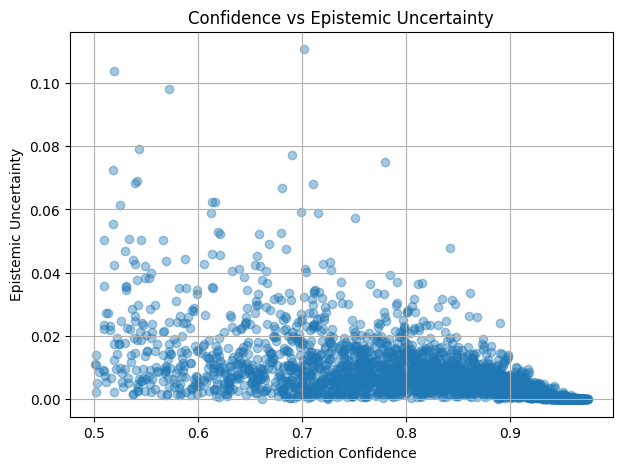

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,5))
plt.scatter(all_confidence, all_epistemic, alpha=0.4)
plt.xlabel("Prediction Confidence")
plt.ylabel("Epistemic Uncertainty")
plt.title("Confidence vs Epistemic Uncertainty")
plt.grid(True)
plt.show()


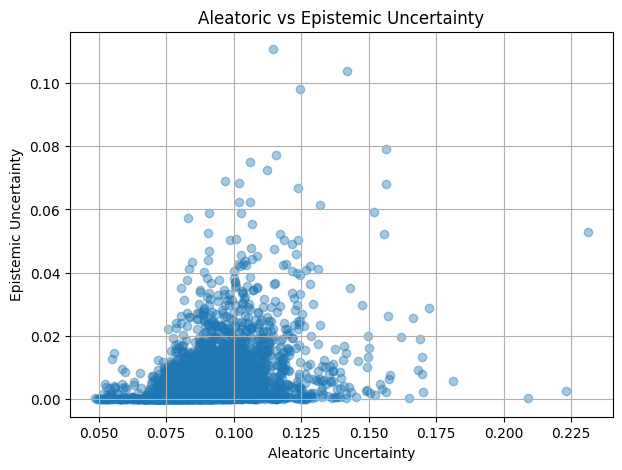

In [63]:
plt.figure(figsize=(7,5))
plt.scatter(all_aleatoric, all_epistemic, alpha=0.4)
plt.xlabel("Aleatoric Uncertainty")
plt.ylabel("Epistemic Uncertainty")
plt.title("Aleatoric vs Epistemic Uncertainty")
plt.grid(True)
plt.show()


In [64]:
from sklearn.metrics import accuracy_score

epistemic = np.array(all_epistemic)
labels = np.array(all_labels)
preds = np.array(all_preds)

rejection_rates = np.linspace(0, 0.5, 11)  # reject up to 50%
accuracies = []

for r in rejection_rates:
    threshold = np.percentile(epistemic, 100 * (1 - r))
    keep_idx = epistemic < threshold

    if keep_idx.sum() == 0:
        accuracies.append(0)
    else:
        acc = accuracy_score(labels[keep_idx], preds[keep_idx])
        accuracies.append(acc)


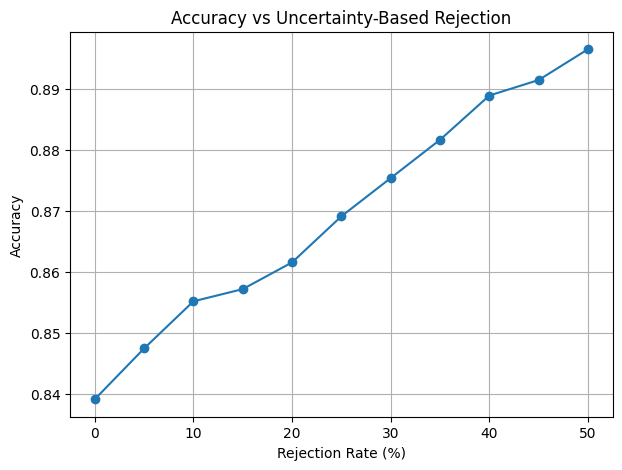

In [65]:
plt.figure(figsize=(7,5))
plt.plot(rejection_rates * 100, accuracies, marker='o')
plt.xlabel("Rejection Rate (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Uncertainty-Based Rejection")
plt.grid(True)
plt.show()


In [66]:
import numpy as np

conf = np.array(all_confidence)
preds = np.array(all_preds)
labels = np.array(all_labels)


In [67]:
sorted_idx = np.argsort(-conf)

conf_sorted = conf[sorted_idx]
preds_sorted = preds[sorted_idx]
labels_sorted = labels[sorted_idx]


In [68]:
coverage = []
accuracy = []

N = len(labels_sorted)

for k in range(10, 101, 5):  # 10% → 100%
    cutoff = int(N * k / 100)

    preds_k = preds_sorted[:cutoff]
    labels_k = labels_sorted[:cutoff]

    acc_k = (preds_k == labels_k).mean()

    coverage.append(k / 100)
    accuracy.append(acc_k)


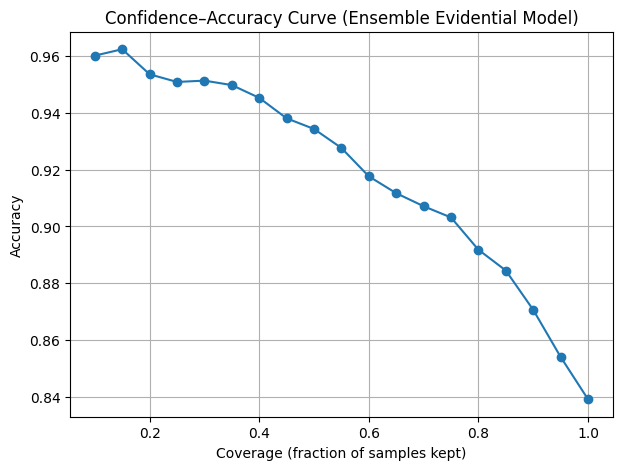

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(coverage, accuracy, marker='o')
plt.xlabel("Coverage (fraction of samples kept)")
plt.ylabel("Accuracy")
plt.title("Confidence–Accuracy Curve (Ensemble Evidential Model)")
plt.grid(True)
plt.show()


In [70]:
import numpy as np

conf = np.array(all_confidence)
preds = np.array(all_preds)
labels = np.array(all_labels)


In [71]:
sorted_idx = np.argsort(-conf)

preds_sorted = preds[sorted_idx]
labels_sorted = labels[sorted_idx]


In [72]:
coverage = []
risk = []

N = len(labels_sorted)

for k in range(10, 101, 5):   # 10% → 100%
    cutoff = int(N * k / 100)

    preds_k = preds_sorted[:cutoff]
    labels_k = labels_sorted[:cutoff]

    acc_k = (preds_k == labels_k).mean()
    risk_k = 1.0 - acc_k

    coverage.append(k / 100)
    risk.append(risk_k)


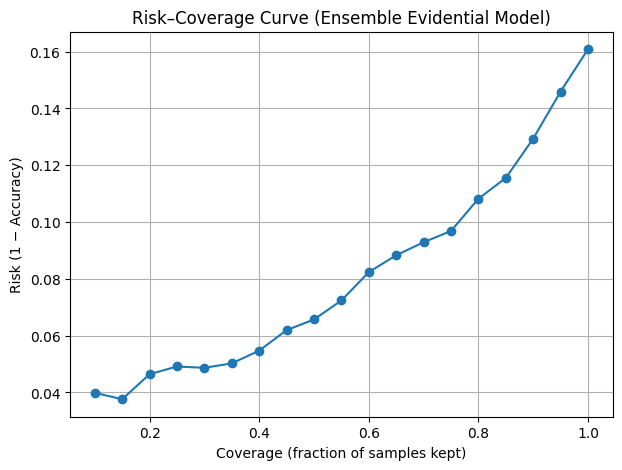

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(coverage, risk, marker='o')
plt.xlabel("Coverage (fraction of samples kept)")
plt.ylabel("Risk (1 − Accuracy)")
plt.title("Risk–Coverage Curve (Ensemble Evidential Model)")
plt.grid(True)
plt.show()


Area Under Risk–Coverage (lower is better):

In [75]:
from sklearn.metrics import auc

aurc = auc(coverage, risk)
print("AURC:", aurc)


AURC: 0.07233484069246632


In [76]:
score = -np.array(all_epistemic)  # lower epistemic = higher confidence


In [77]:
import numpy as np

conf = np.array(all_confidence)
preds = np.array(all_preds)
labels = np.array(all_labels)

correct = (preds == labels).astype(int)


In [78]:
n_bins = 10
bins = np.linspace(0.0, 1.0, n_bins + 1)

bin_acc = []
bin_conf = []
bin_count = []


In [79]:
for i in range(n_bins):
    idx = (conf >= bins[i]) & (conf < bins[i+1])

    if idx.sum() > 0:
        bin_acc.append(correct[idx].mean())
        bin_conf.append(conf[idx].mean())
        bin_count.append(idx.sum())
    else:
        bin_acc.append(0)
        bin_conf.append(0)
        bin_count.append(0)


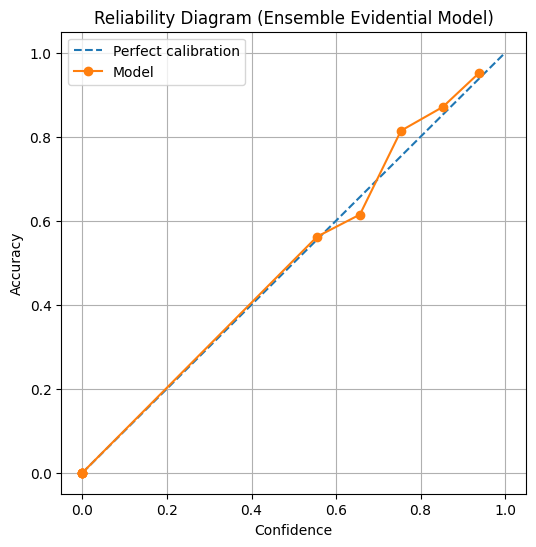

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], '--', label="Perfect calibration")
plt.plot(bin_conf, bin_acc, marker='o', label="Model")

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram (Ensemble Evidential Model)")
plt.legend()
plt.grid(True)
plt.show()


In [81]:
ece = 0.0
N = len(conf)

for i in range(n_bins):
    if bin_count[i] > 0:
        ece += (bin_count[i] / N) * abs(bin_acc[i] - bin_conf[i])

print("ECE:", ece)


ECE: 0.02795730999255459


Epistemic vs Aleatoric Scatter Plot

In [82]:
epi = np.array(all_epistemic)
ale = np.array(all_aleatoric)


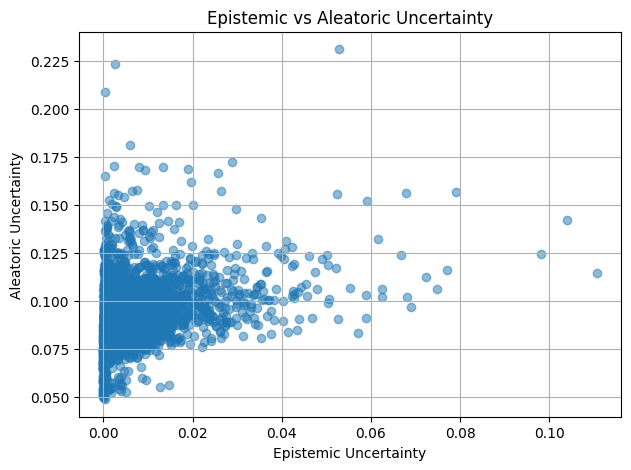

In [83]:
plt.figure(figsize=(7,5))
plt.scatter(epi, ale, alpha=0.5)

plt.xlabel("Epistemic Uncertainty")
plt.ylabel("Aleatoric Uncertainty")
plt.title("Epistemic vs Aleatoric Uncertainty")

plt.grid(True)
plt.show()


In [84]:
percentiles = [0, 25, 50, 75]

rows = []

for p in percentiles:
    threshold = np.percentile(epi, p)
    idx = epi <= threshold

    coverage = idx.mean()
    acc = (preds[idx] == labels[idx]).mean()

    rows.append([p, coverage, acc])


In [85]:
import pandas as pd

df_selective = pd.DataFrame(
    rows,
    columns=["Epistemic Rejection (%)", "Coverage", "Accuracy"]
)

df_selective


,Epistemic Rejection (%),Coverage,Accuracy
0,0,0.000332,1.000000
1,25,0.250083,0.938992
2,50,0.500166,0.896552
3,75,0.749917,0.869084


In [86]:
import numpy as np
import pandas as pd

epi = np.array(all_epistemic)
preds = np.array(all_preds)
labels = np.array(all_labels)


In [87]:
rejection_percents = [0, 25, 50, 75]

rows = []
N = len(epi)


In [88]:
for r in rejection_percents:
    # reject r% most uncertain samples
    threshold = np.percentile(epi, 100 - r)

    # keep only low-uncertainty samples
    idx = epi <= threshold

    coverage = idx.mean()
    accuracy = (preds[idx] == labels[idx]).mean()

    rows.append([r, coverage, accuracy])


In [89]:
df_rejection = pd.DataFrame(
    rows,
    columns=["Epistemic Rejection (%)", "Coverage", "Accuracy"]
)

df_rejection


,Epistemic Rejection (%),Coverage,Accuracy
0,0,1.000000,0.839138
1,25,0.749917,0.869084
2,50,0.500166,0.896552
3,75,0.250083,0.938992
